In [2]:
import torch
import numpy as np
import tensorflow as tf
from transformers import RobertaTokenizer
import torch.nn.functional as F

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image as keras_image

In [3]:
# ===== DEVICE =====
device = torch.device("cpu")

In [4]:
# ===== LOAD TEXT MODEL =====
tokenizer = RobertaTokenizer.from_pretrained("saved_model/tokenizer")

model = MultiTaskRoBERTa()
model.load_state_dict(torch.load("saved_model/model.pt", map_location=device))
model.to(device)
model.eval()

print("✅ Text model loaded")

✅ Text model loaded


In [5]:
# ===== LOAD IMAGE MODEL =====
IMAGE_MODEL_PATH = r"C:\Users\HP\Documents\Major_Final\Github-code\Module-2_Mini-2\Notebooks\resnet50_disaster_finetuned.keras"
image_model = tf.keras.models.load_model(IMAGE_MODEL_PATH)
print("✅ Image model loaded")

✅ Image model loaded


In [6]:
# ===== TEXT PREDICTION =====
def predict_text(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)

    with torch.no_grad():
        out_d, _ = model(**inputs)   # only disaster head used

        prob = F.softmax(out_d, dim=1)

    return prob.cpu().numpy()[0]

In [7]:
# ===== IMAGE PREDICTION =====
def predict_image(img_path):
    img = keras_image.load_img(img_path, target_size=(224, 224))
    x = keras_image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = tf.keras.applications.resnet50.preprocess_input(x)

    preds = image_model.predict(x)
    
    # IMPORTANT: convert multi-class → binary
    disaster_score = np.sum(preds[0][:5])   # disaster classes
    non_disaster_score = preds[0][5]        # Non Damage

    return np.array([non_disaster_score, disaster_score])

In [8]:
# ===== DECISION FUSION =====
def decision_fusion(text_prob, image_prob, w_text=0.7, w_img=0.3):
    fused = (w_text * text_prob) + (w_img * image_prob)
    return np.argmax(fused)

In [9]:
# ===== SAMPLE TEST DATA =====
test_data = pd.read_csv("test.csv")

y_true = []
y_pred = []


# ===== RUN INFERENCE =====
for sample in test_data:
    text = sample["text"]
    img = sample["image"]

    text_prob = predict_text(text)
    image_prob = predict_image(img)

    pred = decision_fusion(text_prob, image_prob)

    y_true.append(sample["label"])
    y_pred.append(pred)

In [10]:
# ===== METRICS =====
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

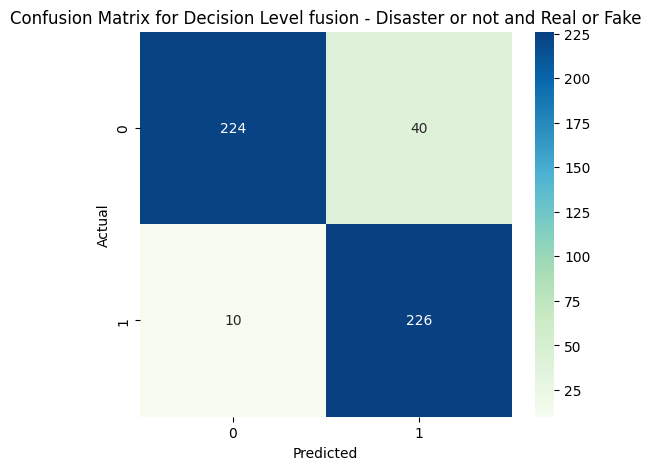

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='GnBu')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Decision Level fusion - Disaster or not and Real or Fake")

plt.show()

In [13]:
# ===== FINAL PRINT =====
print("\nFusion Text + Image (Proposed System)")
print(f"{acc:.4f} {prec:.4f} {rec:.4f} {f1:.4f}")


Fusion Text + Image (Proposed System)
0.9050 0.8980 0.9030 0.9097
